# 11_04.Sentiment Analysis(감성분석)
- https://konlpy.org/ko/latest/api/konlpy.tag/

## 1.기본 package 설정

In [ ]:
# 단어 빈도 및 워드 클라우드에 한글 인식하기기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

#  *** 런타임 다시 시작

### 1.2 KoNLPY 세팅

In [ ]:
! pip install konlpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 50.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.3/465.3 kB 28.7 MB/s eta 0:00:00


### 1.3 package 설정

In [ ]:
## 1.기본
import numpy as np  # numpy 패키지 가져오기
import pandas as pd # pandas 패키지 가져오기
import matplotlib.pyplot as plt # 시각화 패키지 가져오기
import seaborn as sns # 시각화

## 2.데이터 전처리
import re                             # 정규식 모듈 임포트

## 3.형태소 처리
from konlpy.tag import Okt

## 4.
import nltk
from collections import Counter
from wordcloud import WordCloud

## 2.데이터 가져오기

### 2.1 구글 드라이브와 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
tm_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/tm.csv', encoding="cp949")
tm_df.head()

,no,구분,전공,본문
0,1,post,전공,코로나19라는 펜데믹 상황에서 \n사람이 모이면 안되는 상황인지라 실험을 진행하는데...
1,2,pre,교양,"3시간이라는 시간이 조금 길 수도 있겠다는 생각이 들지만, 필요한 정보를 많이 얻을..."
2,3,pre,교양,가장 특이하지만 또 가장 이상적인 모습의 교수님이었습니다 나무가 아닌 숲을 보는 수...
3,4,pre,교양,"각자의 생각이 다르고, 대학에 온 이유도 다를텐데, 동영상 ucc제작을 하는 이유를..."
4,5,pre,교양,강사님에 따라 강의 시간이 좋기도 하고 지루하기도 했다.


In [ ]:
tm_df.info()

In [ ]:
tm_df['본문'].iloc[0]

### 2.2 문서 전처리 및 동음이의어 정리
- 기본적인 문서 전처리 작업을 하고
- 단어빈도분석을 한 후에, 문제 있는 단어를 찾은 후에 정리


In [ ]:
tm_list = []

for i in range(len(tm_df)):
    text = tm_df['본문'].iloc[i]
    text = re.sub('[\x00-\x1F\x7F]', "", text)                # 제어문자[\n, \t] 제거 [[:cntrl:]]
    text = re.sub("[\W]", " ", text)                          # 구두점 등 제거 - 문자와 숫자만 저장
    #text = re.sub("[^\D]", " ", text)                         # 숫자제거
    text = re.sub('(Zoom 수업|Zoom수업|줌 수업)', '줌수업', text)
    text = re.sub('강의', '수업', text)
    tm_list.append(text)

# 2개 단어를 한단어로 통합
# re.sub('(강서 대학교|강서대학|강서 대학)', '강서대학교', text)

# 같은 단어를 한 단어로 변경
# re.sub("공부\\w*", "공부", word)
# re.sub("\\w*\\습니\\w*", "삭제", word)

In [ ]:
tm_list[0]

## 3.형태소로 분리 및 전처리
- https://konlpy.org/ko/latest/api/konlpy.tag/
- 명사와 동사 추출
- 한단어 삭제
- 동사만 추출은 부록 참고
- 불용어 제거: 단어빈도분석을 한 후에, 문제 있는 단어를 찾은 후에 불용어 제거



In [ ]:
# 명사와 동사추출
okt = Okt()
words_list = []
stop_words = ["하다", "있다", "되어다"]

for i in range(len(tm_list)):
    text = tm_list[i]
    morp = okt.pos(text, stem=True) # stem = 동사 원형 추출

    # 명사와 동사/형용사 추출, 한 글자 단어 삭제, 불용어 제거
    for word, tag in morp:
        if ((tag == 'Noun' or tag == 'Verb' or tag == 'Adjective')
             and (len(word) > 1)
             and (word not in stop_words)):
            words_list.append(word)

words_list

['코로나',
 '펜데믹',
 '상황',
 '사람',
 '모이',
 '안되다',
 '상황',
 '인지',
 '실험',
 '진행',
 '조금',
 '불편하다',
 '최대한',
 '서로',
 '피해',
 '주지',
 '않다',
 '수업',
 '진행',
 '해주다',
 '좋다',
 '또한',
 '수업',
 '방식',
 '과제',
 '제출',
 '대해',
 '불편하다',
 '생기',
 '바로',
 '피드백',
 '주시',
 '해결',
 '찾다',
 '좋다',
 '수업',
 '파일',
 '누락',
 '되다',
 '생기다',
 '늦다',
 '올려주다',
 '좋다',
 '다만',
 '공지',
 '조금',
 '느리다',
 '생각',
 '들다',
 '공지',
 '조금',
 '빨르다',
 '좋다',
 '생각',
 '들다',
 '대학',
 '교수',
 '교수',
 '수업',
 '시간',
 '조금',
 '수도',
 '생각',
 '들다',
 '필요하다',
 '정보',
 '얻다',
 '값지다',
 '시간',
 '이다',
 '가장',
 '특이하다',
 '가장',
 '이상',
 '모습',
 '교수',
 '이다',
 '나무',
 '아니다',
 '보다',
 '수업',
 '같다',
 '학생',
 '이름',
 '외우다',
 '같다',
 '다음',
 '다른',
 '수업',
 '다시',
 '배우다',
 '싶다',
 '각자',
 '생각',
 '다르다',
 '대학',
 '이유',
 '다르다',
 '동영상',
 '제작',
 '이유',
 '자다',
 '모르다',
 '강사',
 '따르다',
 '수업',
 '시간',
 '좋다',
 '기도',
 '지루하다',
 '수업',
 '자료',
 '파워포인트',
 '가시',
 '효과',
 '내지',
 '경우',
 '많다',
 '빼곡',
 '적히다',
 '피피티',
 '자료',
 '수업',
 '집중',
 '요점',
 '흐리다',
 '또한',
 '교수',
 '빠르다',
 '속도',
 '샛길',
 '빠지다',
 '주제가',
 '수업',
 '내용',
 '혼잡하다',
 '토론',


## 4.감성사전 만들기

### 4.1 감성사전 불러오기

In [ ]:
senti_dic_df = pd.read_table('/content/drive/MyDrive/Colab Notebooks/SentiWord_Dict.txt',
                             sep = "\t",
                             names = ['word', 'score'])
senti_dic_df.head()

,word,score
0,(-;,1
1,(;_;),-1
2,(^^),1
3,(^-^),1
4,(^^*,1


In [ ]:
senti_dic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14855 entries, 0 to 14854
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   word    14855 non-null  object
 1   score   14855 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 232.2+ KB


In [ ]:
# 감성사전 갯수 확인
senti_dic_df['score'].value_counts()

-1    5031
-2    4799
 2    2603
 1    2268
 0     154
Name: score, dtype: int64

### 4.2 감성사전 만들기

In [ ]:
senti_dic_df['감정점수'] = np.select([senti_dic_df['score'] >= 1,
                                      senti_dic_df['score'] <= -1,
                                      senti_dic_df['score'] ==  0 ],
           ['긍정','부정','중립'] )
senti_dic_df.head()

,word,score,감정점수
0,(-;,1,긍정
1,(;_;),-1,부정
2,(^^),1,긍정
3,(^-^),1,긍정
4,(^^*,1,긍정


부정    9830
긍정    4871
중립     154
Name: 감정점수, dtype: int64 Axes(0.125,0.11;0.775x0.77)


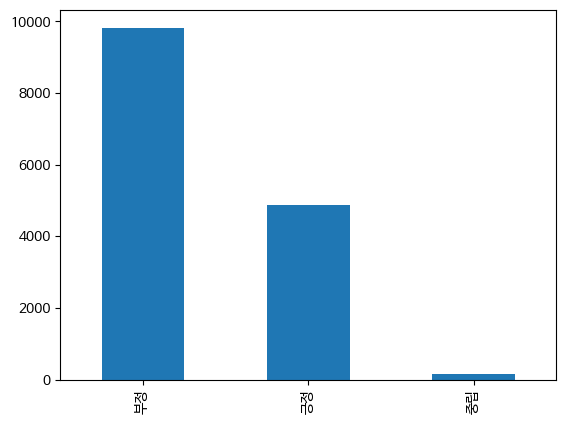

In [ ]:
plt.rc('font', family='NanumBarunGothic')
print(senti_dic_df['감정점수'].value_counts(),
      senti_dic_df['감정점수'].value_counts().plot.bar())

## 5.감성분석

In [ ]:
words_list_df = pd.DataFrame(words_list, columns= ['word'])
join_df = pd.merge(words_list_df, senti_dic_df, how='inner')
join_df

,word,score,감정점수
0,불편하다,-2,부정
1,불편하다,-2,부정
2,불편하다,-2,부정
3,불편하다,-2,부정
4,불편하다,-2,부정
...,...,...,...
5281,질환,-2,부정
5282,질환,-2,부정
5283,질병,-2,부정
5284,질병,-2,부정


In [ ]:
senti_counts = join_df.groupby("word")['score'].sum().reset_index() # reset_index(): word(열) 추출
senti_counts['n'] = senti_counts["score"].abs()
senti_counts.sort_values(["score"],
                         ascending= False ,
                         inplace=True)
senti_counts

,word,score,n
284,좋다,2042,2042
7,감사하다,824,824
100,많다,778,778
6,감사,236,236
130,배우다,184,184
...,...,...,...
196,아쉽다,-111,111
221,없다,-201,201
364,힘들다,-208,208
194,아니다,-248,248


In [ ]:
senti_counts['category'] = np.select([senti_counts['score'] >= 1,
                                      senti_counts['score'] <= -1,
                                      senti_counts['score'] ==  0],
                                     ['긍정','부정','중립'])
senti_counts

,word,score,n,category
284,좋다,2042,2042,긍정
7,감사하다,824,824,긍정
100,많다,778,778,긍정
6,감사,236,236,긍정
130,배우다,184,184,긍정
...,...,...,...,...
196,아쉽다,-111,111,부정
221,없다,-201,201,부정
364,힘들다,-208,208,부정
194,아니다,-248,248,부정


## 6.단어빈도분석

### 6.1 단어빈도 그래프 (긍정/부정 분리)

In [ ]:
filter = (senti_counts["category"] == "긍정")
senti_counts_pos = senti_counts.loc[filter, ["word",'n']][:20]
senti_counts_pos

NameError: ignored

In [ ]:
senti_counts.sort_values(["score"],
                         ascending = True ,
                         inplace = True)
filter = (senti_counts["category"] == "부정")
senti_counts_neg = senti_counts.loc[filter, ["word",'n']][:20]
senti_counts_neg

,word,n
213,어렵다,390
194,아니다,248
364,힘들다,208
221,없다,201
196,아쉽다,111
212,어려움,98
155,불편하다,94
138,부담,60
66,늦다,39
145,부족하다,33


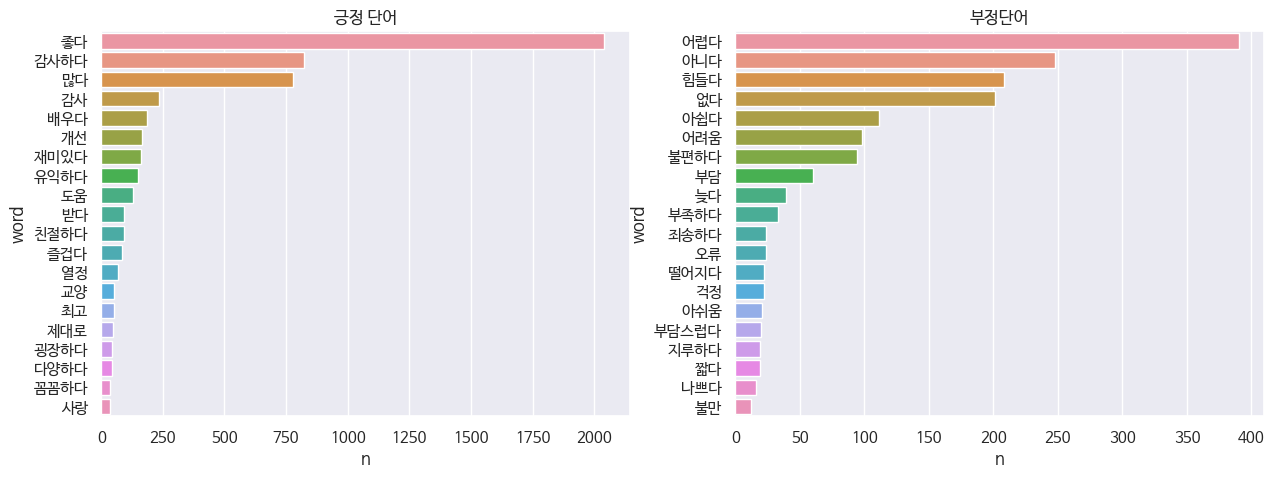

In [ ]:
plt.rc('font', family='NanumBarunGothic')

fig ,ax = plt.subplots(1, 2, figsize=(15, 5))
plt.subplot(1,2, 1)
plt.title("긍정 단어")
sns.barplot(y = "word", x = "n", data = senti_counts_pos)
plt.subplot(1,2, 2)
plt.title("부정단어")
sns.barplot(y="word", x="n", data = senti_counts_neg)
plt.show()

### 6.2 단어빈도 그래프 (긍정/부정 통합)

In [ ]:
filter = (senti_counts["category"] == "긍정")
senti_counts_pos = senti_counts.loc[filter, ["word",'score']][:20]
senti_counts_pos

,word,score
284,좋다,2042
7,감사하다,824
100,많다,778
6,감사,236
130,배우다,184
9,개선,166
270,재미있다,160
245,유익하다,150
77,도움,130
127,받다,94


In [ ]:
senti_counts.sort_values(["score"],
                         ascending = True ,
                         inplace = True)
filter = (senti_counts["category"] == "부정")
senti_counts_neg = senti_counts.loc[filter, ["word",'score']][:20]
senti_counts_neg

,word,score
213,어렵다,-390
194,아니다,-248
364,힘들다,-208
221,없다,-201
196,아쉽다,-111
212,어려움,-98
155,불편하다,-94
138,부담,-60
66,늦다,-39
145,부족하다,-33


In [ ]:
senti_word_total = pd.concat([senti_counts_pos, senti_counts_neg], axis=0)
senti_word_total.sort_values(["score"],
                             ascending = False ,
                             inplace = True)

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


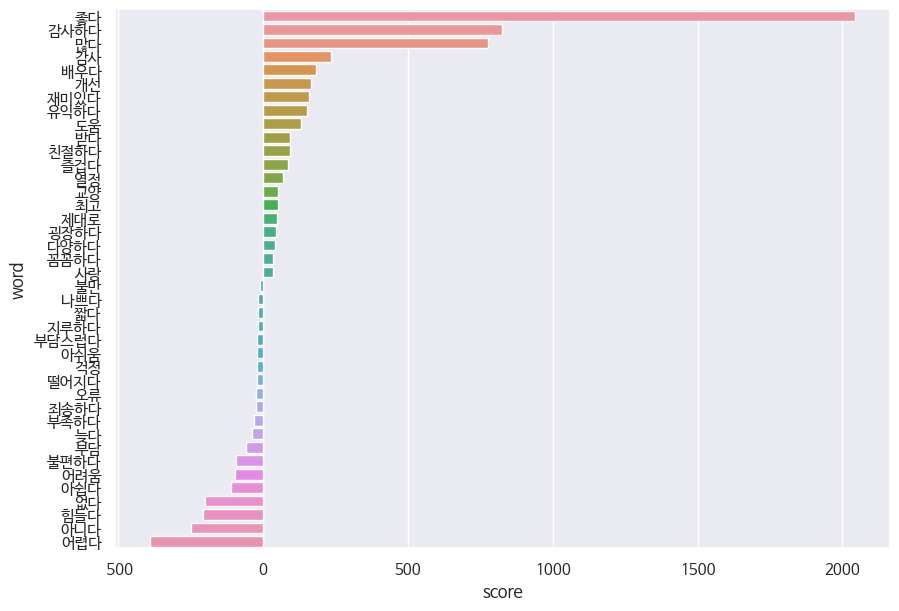

In [ ]:
# 그래프 그리기
fig ,ax = plt.subplots(figsize=(10, 7))
sns.set(font_scale = 1)
ax = sns.barplot(y="word",
                 x="score",
                 data = senti_word_total)
plt.rc('font', family = 'NanumBarunGothic')
plt.show()

### 6.3 WordColud(긍정부정 구분)

In [ ]:
# 감정단어 카운트
# wordcoud에 넣기 위해서 n을 이용함 (색깔로 구분함)

senti_counts_wc = pd.DataFrame({"index": senti_counts["word"],
                               "word": senti_counts["n"]})
senti_counts_wc = senti_counts_wc.values.tolist()
senti_counts_wc

[['어렵다', 390],
 ['아니다', 248],
 ['힘들다', 208],
 ['없다', 201],
 ['아쉽다', 111],
 ['어려움', 98],
 ['불편하다', 94],
 ['부담', 60],
 ['늦다', 39],
 ['부족하다', 33],
 ['죄송하다', 24],
 ['오류', 24],
 ['떨어지다', 22],
 ['걱정', 22],
 ['아쉬움', 21],
 ['부담스럽다', 20],
 ['지루하다', 19],
 ['짧다', 19],
 ['나쁘다', 16],
 ['불만', 12],
 ['짜증', 12],
 ['잘못', 12],
 ['틀리다', 12],
 ['지다', 12],
 ['비판', 11],
 ['아프다', 10],
 ['두려움', 10],
 ['딱하다', 10],
 ['버겁다', 10],
 ['안타깝다', 10],
 ['최악', 10],
 ['버리다', 10],
 ['실망', 10],
 ['무섭다', 8],
 ['막막하다', 8],
 ['심하다', 8],
 ['놓치다', 8],
 ['위험하다', 8],
 ['결석', 8],
 ['지나치다', 8],
 ['장애', 6],
 ['억울하다', 6],
 ['아깝다', 6],
 ['스트레스', 6],
 ['없애다', 6],
 ['시끄럽다', 6],
 ['후회', 6],
 ['폭력', 6],
 ['피해', 6],
 ['충격', 5],
 ['당하다', 5],
 ['어긋나다', 5],
 ['느리다', 4],
 ['장애인', 4],
 ['질환', 4],
 ['싫다', 4],
 ['잃다', 4],
 ['불만족', 4],
 ['속상하다', 4],
 ['불안', 4],
 ['밉다', 4],
 ['더럽다', 4],
 ['불쾌하다', 4],
 ['불편', 4],
 ['부적절하다', 4],
 ['두렵다', 4],
 ['막히다', 4],
 ['바보', 4],
 ['한계', 4],
 ['울다', 4],
 ['포기', 4],
 ['번거롭다', 4],
 ['비싸다', 4],
 ['상처', 4],
 ['막연하다', 

In [ ]:
# 색깔을 구분하기 위해 word dictionary 만듬
word_dic = join_df.groupby("word")['score'].sum()
word_dic = word_dic.to_dict()
word_dic

{'가능하다': 18,
 '가르침': 10,
 '가치': 6,
 '간편하다': 2,
 '감기': -1,
 '감동': 10,
 '감사': 236,
 '감사하다': 824,
 '강하다': 4,
 '개선': 166,
 '거짓말': -2,
 '걱정': -22,
 '건강하다': 20,
 '걸리다': -2,
 '결석': -8,
 '겸손하다': 2,
 '고급': 2,
 '고르다': 2,
 '고맙다': 6,
 '고집': -1,
 '고충': -2,
 '고치다': 10,
 '고통스럽다': -2,
 '곤란하다': -2,
 '곱다': 4,
 '공정하다': 10,
 '공평하다': 4,
 '과로': -1,
 '괜찮다': 10,
 '괴롭다': -2,
 '굉장하다': 44,
 '교양': 53,
 '교훈': 1,
 '귀엽다': 4,
 '귀중하다': 2,
 '귀찮다': -3,
 '귀하다': 10,
 '그러하다': 3,
 '그립다': 1,
 '급하다': -2,
 '긍정': 4,
 '기대': 7,
 '기대하다': 7,
 '기쁘다': 12,
 '기쁨': 2,
 '까다롭다': -2,
 '깔끔하다': 22,
 '깨닫다': 3,
 '깨달음': 2,
 '깨지다': -1,
 '꼼꼼하다': 35,
 '꿀잼': 1,
 '나쁘다': -16,
 '나아지다': 6,
 '난잡하다': -2,
 '난해하다': -2,
 '낯설다': -2,
 '너그럽다': 4,
 '너무하다': -2,
 '놀랍다': 1,
 '높다': 31,
 '높이다': 7,
 '놓치다': -8,
 '느리다': -4,
 '늘어나다': -3,
 '능력': 17,
 '늦다': -39,
 '늦어지다': -2,
 '다양하다': 42,
 '답답하다': -2,
 '당하다': -5,
 '대상': 4,
 '더디다': -1,
 '더럽다': -4,
 '더하다': 4,
 '도둑': -1,
 '도와주다': 20,
 '도움': 130,
 '독특하다': 1,
 '돋보이다': 1,
 '돕다': 10,
 '두려움': -10,
 '두렵다': -4,
 '따뜻하다': 14,
 '딱하다': 

In [ ]:
# 긍정단어, 부정단어 구분
pos_words = []
neg_words = []
for key, value in word_dic.items():
    if value >= 1:
        pos_words.append(key)
    else:
        neg_words.append(key)

print(pos_words)
print(neg_words)

['가능하다', '가르침', '가치', '간편하다', '감동', '감사', '감사하다', '강하다', '개선', '건강하다', '겸손하다', '고급', '고르다', '고맙다', '고치다', '곱다', '공정하다', '공평하다', '괜찮다', '굉장하다', '교양', '교훈', '귀엽다', '귀중하다', '귀하다', '그러하다', '그립다', '긍정', '기대', '기대하다', '기쁘다', '기쁨', '깔끔하다', '깨닫다', '깨달음', '꼼꼼하다', '꿀잼', '나아지다', '너그럽다', '놀랍다', '높다', '높이다', '능력', '다양하다', '대상', '더하다', '도와주다', '도움', '독특하다', '돋보이다', '돕다', '따뜻하다', '뚜렷하다', '뛰어나다', '만족', '만족스럽다', '만족하다', '많다', '매끄럽다', '멋있다', '멋지다', '명성', '명쾌하다', '믿다', '믿음', '바람직하다', '바르게', '바르다', '반갑다', '받다', '발전', '밝다', '배우다', '보람', '부드럽다', '분명하다', '빠르다', '사랑', '상냥하다', '상위', '생겨나다', '생생하다', '소중하다', '솔직하다', '수월하다', '순수하다', '시원시원하다', '신기하다', '신뢰', '신선하다', '신중하다', '실속', '아끼다', '안도', '안심', '안정', '안정감', '알맞다', '애착', '어울리다', '어질다', '여유', '열정', '영광', '예방', '예쁘다', '예의', '올바르다', '옳다', '완벽하다', '완성', '용기', '위트', '유명하다', '유용하다', '유익하다', '유쾌하다', '융통성', '은혜', '의욕', '이기다', '이루다', '이루어지다', '이쁘다', '인정', '인정받다', '자랑스럽다', '자신감', '자질', '장점', '장학금', '재미', '재미있다', '적극', '적당하다', '적합하다', '젊다', '정상', '정성껏', '정중하다', '제대로', '조화'

In [ ]:
color_words_dict = {
    "green" : pos_words,
    "red" : neg_words
}
color_words_dict

{'green': ['가능하다',
  '가르침',
  '가치',
  '간편하다',
  '감동',
  '감사',
  '감사하다',
  '강하다',
  '개선',
  '건강하다',
  '겸손하다',
  '고급',
  '고르다',
  '고맙다',
  '고치다',
  '곱다',
  '공정하다',
  '공평하다',
  '괜찮다',
  '굉장하다',
  '교양',
  '교훈',
  '귀엽다',
  '귀중하다',
  '귀하다',
  '그러하다',
  '그립다',
  '긍정',
  '기대',
  '기대하다',
  '기쁘다',
  '기쁨',
  '깔끔하다',
  '깨닫다',
  '깨달음',
  '꼼꼼하다',
  '꿀잼',
  '나아지다',
  '너그럽다',
  '놀랍다',
  '높다',
  '높이다',
  '능력',
  '다양하다',
  '대상',
  '더하다',
  '도와주다',
  '도움',
  '독특하다',
  '돋보이다',
  '돕다',
  '따뜻하다',
  '뚜렷하다',
  '뛰어나다',
  '만족',
  '만족스럽다',
  '만족하다',
  '많다',
  '매끄럽다',
  '멋있다',
  '멋지다',
  '명성',
  '명쾌하다',
  '믿다',
  '믿음',
  '바람직하다',
  '바르게',
  '바르다',
  '반갑다',
  '받다',
  '발전',
  '밝다',
  '배우다',
  '보람',
  '부드럽다',
  '분명하다',
  '빠르다',
  '사랑',
  '상냥하다',
  '상위',
  '생겨나다',
  '생생하다',
  '소중하다',
  '솔직하다',
  '수월하다',
  '순수하다',
  '시원시원하다',
  '신기하다',
  '신뢰',
  '신선하다',
  '신중하다',
  '실속',
  '아끼다',
  '안도',
  '안심',
  '안정',
  '안정감',
  '알맞다',
  '애착',
  '어울리다',
  '어질다',
  '여유',
  '열정',
  '영광',
  '예방',
  '예쁘다',
  '예의',
  '올바르다',
  '옳다',
  '완

In [ ]:
# https://amueller.github.io/word_cloud/auto_examples/colored_by_group.html

from wordcloud import (WordCloud, get_single_color_func)

class GroupedColorFunc(object):
    def __init__(self, color_to_words, default_color):
        self.color_func_to_words = [
            (get_single_color_func(color), set(words))
            for (color, words) in color_to_words.items()]

        self.default_color_func = get_single_color_func(default_color)

    def get_color_func(self, word):
        try:
            color_func = next(
                color_func for (color_func, words) in self.color_func_to_words
                if word in words)
        except StopIteration:
            color_func = self.default_color_func

        return color_func

    def __call__(self, word, **kwargs):
        return self.get_color_func(word)(word, **kwargs)

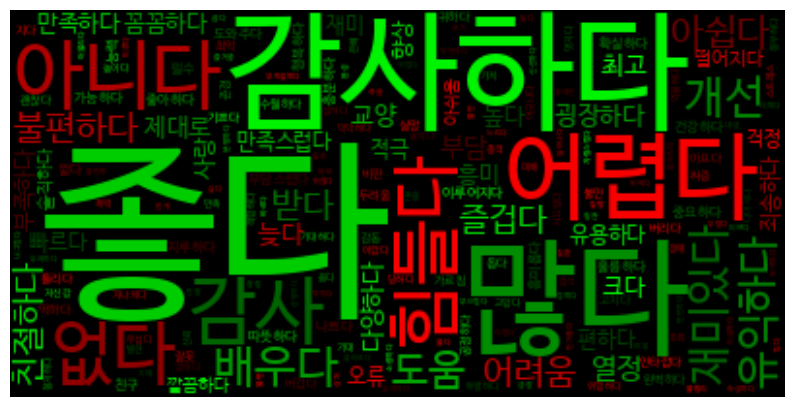

In [ ]:
import matplotlib.font_manager as fm  # 폰트 관련 용도
font_path ='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
#font_name = fm.FontProperties(fname = font_path, size=10).get_name()

wordcloud = WordCloud(font_path = font_path,
                      #background_color='white',
                      max_font_size=100)

cloud = wordcloud.generate_from_frequencies(dict(senti_counts_wc))

color_to_words = color_words_dict

default_color = 'grey'


grouped_color_func = GroupedColorFunc(color_to_words, default_color)
wordcloud.recolor(color_func=grouped_color_func)
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()